In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import py3Dmol
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

from mdm2_breaker import (
    GraphSiameseNetwork_v5,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer,
    SmallMoleculeFeaturizer_v5,
    ProteinSequenceEncoder,
    SequenceSiameseNetwork,
)

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(
    ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

In [3]:
EPOCHS = 100
LR = 1e-4

## Utility Functions

In [4]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

In [5]:
def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)

    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {
        0: "C",
        1: "N",
        2: "O",
        3: "F",
        4: "S",
        5: "Cl",
        6: "Br",
        7: "I",
        8: "?",
    }

    # Create labels and colors for the plot
    labels = {}
    node_colors = []

    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()

        element = atom_map.get(feat_idx, "?")
        labels[node_idx] = f"{node_idx}:{element}"  # Format: "Index:Element"

        # Color logic (CPK-ish coloring)
        if element == "C":
            node_colors.append("gray")
        elif element == "N":
            node_colors.append("blue")
        elif element == "O":
            node_colors.append("red")
        elif element == "S":
            node_colors.append("yellow")
        elif element == "Cl":
            node_colors.append("lightgreen")
        else:
            node_colors.append("orange")

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)  # Force-directed layout

    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        node_size=800,
        font_color="white",
        font_weight="bold",
        edge_color="black",
    )

    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

In [6]:
import torch
import pytorch_lightning as pl
import torch.nn.functional as F
from torch_geometric.data import Data

class SarcomaScoutSystem(pl.LightningModule):
    def __init__(
        self, 
        model: torch.nn.Module, 
        protein_data, 
        lr: float = 0.00005
    ):
        """
        Universal wrapper for Siamese Networks.
        Adapts automatically to Structure-Based (Graph) or Sequence-Based inputs.
        """
        super().__init__()
        self.save_hyperparameters(ignore=["model", "protein_data"])
        self.model = model
        self.lr = lr
        
        if isinstance(protein_data, Data):
            # It's a Graph (Structure-Based)
            self.mode = "graph"
            self.register_buffer("p_x", protein_data.x)
            self.register_buffer("p_edge_index", protein_data.edge_index)
            # Create dummy batch vector [0, 0, 0...]
            batch_vec = torch.zeros(protein_data.x.size(0), dtype=torch.long)
            self.register_buffer("p_batch", batch_vec)
            
        elif isinstance(protein_data, torch.Tensor):
            # It's a Sequence (Sequence-Based)
            self.mode = "sequence"
            # Ensure it is 2D: [1, Seq_Len]
            if protein_data.dim() == 1:
                protein_data = protein_data.unsqueeze(0)
            self.register_buffer("p_seq", protein_data)
            
        else:
            raise ValueError(f"Unknown protein data type: {type(protein_data)}")

    def get_protein_input(self):
        """Reconstructs the correct input object from GPU buffers."""
        if self.mode == "graph":
            return Data(
                x=self.p_x, 
                edge_index=self.p_edge_index, 
                batch=self.p_batch
            )
        else:
            # Return the sequence tensor directly
            return self.p_seq

    def forward(self, protein_input, molecule_data):
        # The model inside handles the specifics (e.g. expanding batch dims)
        return self.model(protein_input, molecule_data)

    def training_step(self, batch, batch_idx):
        # 1. Get the Static Protein (on the correct GPU)
        protein_input = self.get_protein_input()
        molecule_data = batch

        # 2. Predict
        preds = self(protein_input, molecule_data)

        # 3. Loss
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log("train_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_input = self.get_protein_input()
        molecule_data = batch
        preds = self(protein_input, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log("val_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [7]:
def define_trainer(
    epochs=100, lr=1e-4, save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}"
):
    # Checkpoint: Save the model with the lowest Validation Loss
    checkpoint_cb = ModelCheckpoint(
        dirpath="checkpoints/",
        filename=save_name,
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    # Early Stopping: Stop if val_loss doesn't improve for 10 epochs
    early_stop_cb = EarlyStopping(monitor="val_loss", patience=10, mode="min")

    lr_monitor = LearningRateMonitor(logging_interval="epoch")

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="cpu",
        devices=1,
        callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
        log_every_n_steps=10,
    )

    return trainer


def generate_loaders(
    data_class,
    train_indices,
    val_indices,
    test_indices,
    batch_size=64,
    mol_file=mol_file,
):
    data = data_class(
        root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
    )

    train_dataset = data[train_indices]
    val_dataset = data[val_indices]
    test_dataset = data[test_indices]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=7,
        persistent_workers=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )

    return train_loader, val_loader, test_loader


def train_model(
    model,
    mol_class,
    protein_data,
    train_indices,
    val_indices,
    test_indices,
    epochs=100,
    lr=1e-4,
    save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}",
):
    trainer = define_trainer(epochs=epochs, lr=lr, save_name=save_name)

    train_loader, val_loader, test_loader = generate_loaders(
        mol_class, train_indices, val_indices, test_indices
    )

    system = SarcomaScoutSystem(model=model, protein_data=protein_data, lr=lr)

    # trainer.fit(system, train_loader, val_loader)

    return model, train_loader, val_loader, test_loader

In [8]:
def get_metrics(model, data_loader, protein_graph):
    y_pred = []
    y_true = []

    # 1. Collect Data
    with torch.no_grad():  # Good practice to disable gradients here
        for x in data_loader:
            # Predict
            out = model(protein_graph, x).detach().cpu().numpy()
            y_pred.append(out)
            y_true.append(x.y.detach().cpu().numpy())

    # 2. Concatenate and FLATTEN (The Fix)
    y_pred = np.concatenate(y_pred).ravel()  # Force 1D array
    y_true = np.concatenate(y_true).ravel()  # Force 1D array

    # 3. Calculate Correct MSE
    mse = np.mean((y_pred - y_true) ** 2)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

    return mse, r2, y_pred, y_true


def plot_predictions(model, loaders, protein_graph, title):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, loader in enumerate(loaders):
        mse, r2, y_pred, y_true = get_metrics(model, loader, protein_graph)

        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        ax[idx].set_aspect("equal", "box")
        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)
    plt.suptitle(title)
    plt.show()


def plot_xgboost_predictions(
    pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple
):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, (y_pred, y_true, mse) in enumerate(
        [pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple]
    ):
        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        r2 = 1 - (
            np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        )

        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)

    plt.suptitle("XGBoost Predictions")
    plt.show()


In [9]:
def load_model_from_checkpoint(model_class, checkpoint_path):
    # 1. Load the raw checkpoint
    checkpoint = torch.load(checkpoint_path)
    state_dict = checkpoint["state_dict"]

    # 2. Fix the keys (Remove "model." prefix)
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith("model."):
            # Strip the first 6 characters ("model.")
            new_key = key[6:]
            new_state_dict[new_key] = value

    # 3. Initialize your raw model
    model = model_class()

    # 4. Load the cleaned weights
    model.load_state_dict(new_state_dict)
    model.eval()

    return model

In [10]:
def plot_loss(csv_path):
    df = pd.read_csv(csv_path)
    fix, ax = plt.subplots(figsize=(10, 5))

    df.plot(
        x="step",
        y="train_loss",
        title="Training Loss",
        ax=ax,
        label="Training Loss",
        color="blue",
        legend=True,
        style="-",
    )
    df.dropna(subset=["val_loss"]).plot(
        x="step",
        y="val_loss",
        title="Validation Loss",
        ax=ax,
        label="Validation Loss",
        color="red",
        legend=True,
        style="-o",
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Training and Validation Loss")
    ax.legend()
    plt.show()


In [11]:
def plot_xgb_loss(xgb_model):
    # 4. Extract Results
    results = xgb_model.evals_result()
    epochs = len(results["validation_0"]["rmse"])
    x_axis = range(0, epochs)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_axis, results["validation_0"]["rmse"], label="Train")
    ax.plot(x_axis, results["validation_1"]["rmse"], label="Validation")
    ax.plot(x_axis, results["validation_2"]["rmse"], label="Test")
    ax.legend()
    plt.ylabel("RMSE")
    plt.xlabel("n_estimators")
    plt.title("XGBoost Loss vs. n_estimators")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Best Iteration: {xgb_model.best_iteration}")
    print(f"Best Score (Validation MSE): {xgb_model.best_score:.4f}")


## Load Protein Data

In [12]:
protein_data = ProteinFeaturizer(pdb_file=pdb_file)
view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Load Small Molecule Data

In [13]:
mol_data = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
df_mol = pd.read_csv(mol_data.processed_paths[0].replace(".pt", ".csv"))

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smile_to_fingerprint(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.zeros((2048,), dtype=np.float32)

    # NEW CALL
    fp = mfpgen.GetFingerprintAsNumPy(mol)
    return fp


df_mol["fingerprint"] = df_mol["SMILES"].apply(smile_to_fingerprint)
df_mol.head(3)

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm,fingerprint
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


## Prepare Data for Modeling

#### Analyze Data to Ensure Sufficient Splitting

In [14]:
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

def generate_scaffold_split(dataset, frac_train=0.8, frac_val=0.1, frac_test=0.1, seed=42):
    """
    Splits a PyG dataset by Bemis-Murcko scaffolds.
    """
    np.random.seed(seed)
    
    scaffold_to_indices = defaultdict(list)
    
    # 1. Group indices by Scaffold
    print("Generating Scaffolds...")
    for idx, data in enumerate(dataset):
        # We need the SMILES to generate the scaffold. 
        # Ideally, store SMILES in the Data object or look it up in the original DF
        # Assuming dataset.df exists and aligns with dataset indices:
        smiles = dataset.df.iloc[idx]['SMILES']
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None: continue
            
        # Get the core scaffold (removes side chains)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        scaffold_to_indices[scaffold].append(idx)

    # 2. Sort scaffolds by size (to ensure balanced-ish splits)
    # We want to put rare scaffolds in train/val/test somewhat evenly, 
    # but big clusters usually go to train to let the model learn.
    # A common strategy is simply randomizing the *groups*.
    
    scaffolds = list(scaffold_to_indices.keys())
    np.random.shuffle(scaffolds)
    
    train_indices = []
    val_indices = []
    test_indices = []
    
    train_cutoff = frac_train * len(dataset)
    val_cutoff = (frac_train + frac_val) * len(dataset)
    
    # 3. Fill the buckets
    current_count = 0
    
    for scaffold in scaffolds:
        indices = scaffold_to_indices[scaffold]
        
        # If adding this whole cluster keeps us under the train cutoff, add to Train
        if len(train_indices) + len(indices) <= train_cutoff:
            train_indices.extend(indices)
        # Else if we are under the Val cutoff, add to Val
        elif len(train_indices) + len(val_indices) + len(indices) <= val_cutoff:
            val_indices.extend(indices)
        # Else, everything else goes to Test
        else:
            test_indices.extend(indices)
            
    print(f"Split Complete.")
    print(f"Train: {len(train_indices)} molecules")
    print(f"Val:   {len(val_indices)} molecules")
    print(f"Test:  {len(test_indices)} molecules")
    
    return train_indices, val_indices, test_indices

# Usage in your notebook:
train_indices, val_indices, test_indices = generate_scaffold_split(mol_data)

Generating Scaffolds...
Split Complete.
Train: 3229 molecules
Val:   404 molecules
Test:  396 molecules


In [15]:
df_mol['split'] = 'train'
df_mol.loc[val_indices, 'split'] = 'val'
df_mol.loc[test_indices, 'split'] = 'test'
df_mol.to_csv(os.path.join(ROOT, 'data', 'MDM2_Breaker', 'processed', 'benchmark_data.csv'), index=False)
print("Data exported to benchmark_data.csv")

Data exported to benchmark_data.csv


Analyzing Train Set...
Analyzing Test Set...

--- Top 5 Training Scaffolds ---


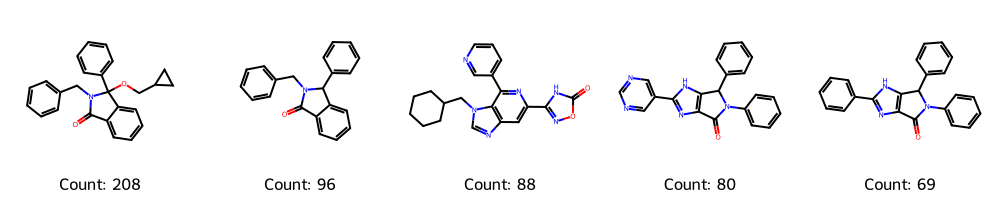


--- Top 5 Test Scaffolds (Should be different!) ---


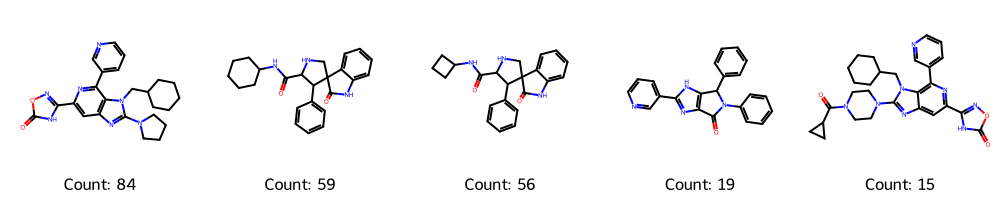


Computing t-SNE (this might take a moment)...


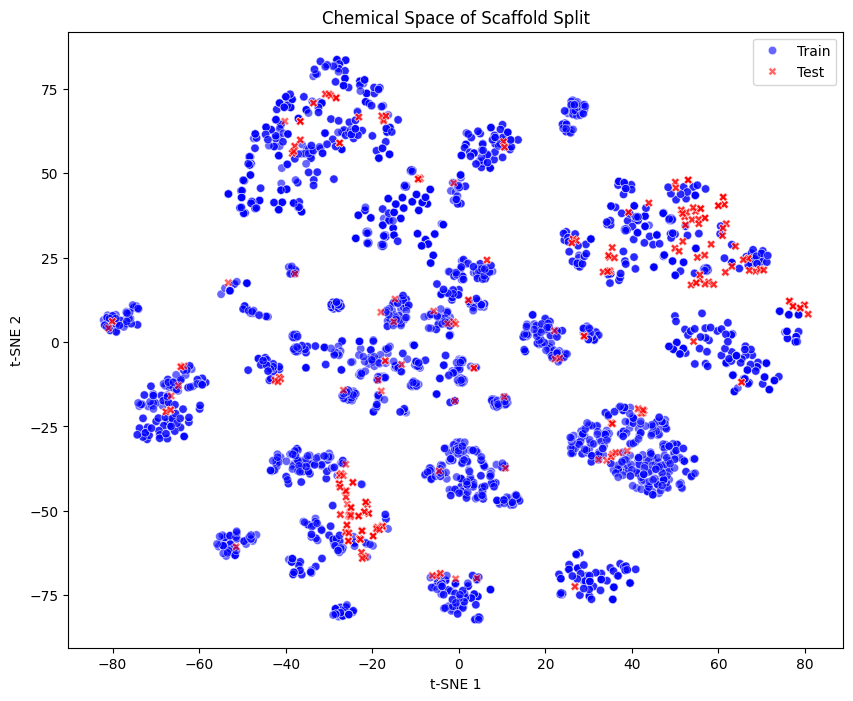

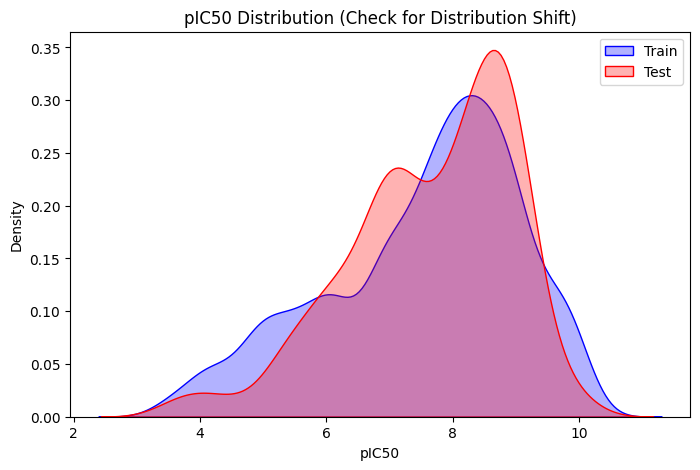

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

def visualize_scaffold_split(dataset, train_idx, val_idx, test_idx):
    """
    Generates a 3-part visualization of the scaffold split.
    1. Grid of Top Train vs. Top Test Scaffolds (Structural Distinctness)
    2. t-SNE plot of Chemical Space (Distribution)
    3. Distribution of pIC50s (Label Shift)
    """
    
    # --- Helper: Get Scaffold & Fingerprint ---
    def get_info(indices, label):
        scaffolds = []
        fps = []
        pics = []
        
        fp_gen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

        for idx in indices:
            smiles = dataset.df.iloc[idx]['SMILES']
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Get Scaffold
                scaff = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
                scaffolds.append(scaff)
                
                # Get Fingerprint (for t-SNE)
                fp = fp_gen.GetFingerprintAsNumPy(mol)
                fps.append(fp)
                
                # Get Label
                pics.append(dataset.df.iloc[idx]['pIC50'])
                
        return scaffolds, np.array(fps), np.array(pics)

    print("Analyzing Train Set...")
    train_scaffs, train_fps, train_y = get_info(train_idx, "Train")
    print("Analyzing Test Set...")
    test_scaffs, test_fps, test_y = get_info(test_idx, "Test")
    
    # --- PLOT 1: The "Face" of the Split (Top Scaffolds) ---
    from collections import Counter
    
    def draw_top_scaffolds(scaff_list, title, n=5):
        counts = Counter(scaff_list)
        top_scaffs = counts.most_common(n)
        
        mols = [Chem.MolFromSmiles(s) for s, c in top_scaffs]
        legends = [f"Count: {c}" for s, c in top_scaffs]
        
        img = Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=(200, 200), legends=legends)
        return img

    print(f"\n--- Top {5} Training Scaffolds ---")
    display(draw_top_scaffolds(train_scaffs, "Top Train Scaffolds"))
    
    print(f"\n--- Top {5} Test Scaffolds (Should be different!) ---")
    display(draw_top_scaffolds(test_scaffs, "Top Test Scaffolds"))

    # --- PLOT 2: Chemical Space t-SNE ---
    print("\nComputing t-SNE (this might take a moment)...")
    
    # Combine for t-SNE to ensure shared space
    X_all = np.vstack([train_fps, test_fps])
    labels = ["Train"] * len(train_fps) + ["Test"] * len(test_fps)
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_all)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_embedded[:, 0], 
        y=X_embedded[:, 1], 
        hue=labels, 
        style=labels,
        alpha=0.6,
        palette={"Train": "blue", "Test": "red"}
    )
    plt.title("Chemical Space of Scaffold Split")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

    # --- PLOT 3: Label Distribution ---
    plt.figure(figsize=(8, 5))
    sns.kdeplot(train_y, fill=True, label="Train", color="blue", alpha=0.3)
    sns.kdeplot(test_y, fill=True, label="Test", color="red", alpha=0.3)
    plt.title("pIC50 Distribution (Check for Distribution Shift)")
    plt.xlabel("pIC50")
    plt.legend()
    plt.show()

# Run it
visualize_scaffold_split(mol_data, train_indices, val_indices, test_indices)

### Split Data into Train/Test/Val

Analyzing Train Set...
Analyzing Test Set...

--- Top 5 Training Scaffolds ---


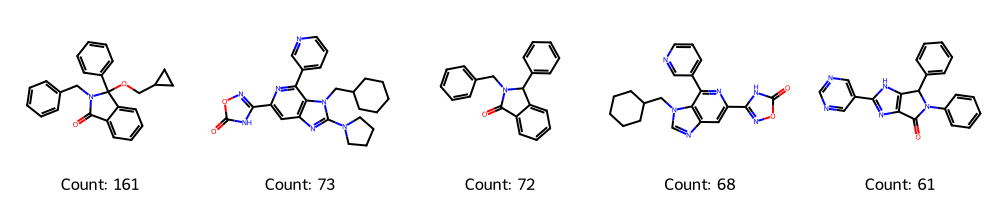


--- Top 5 Test Scaffolds (Should be different!) ---


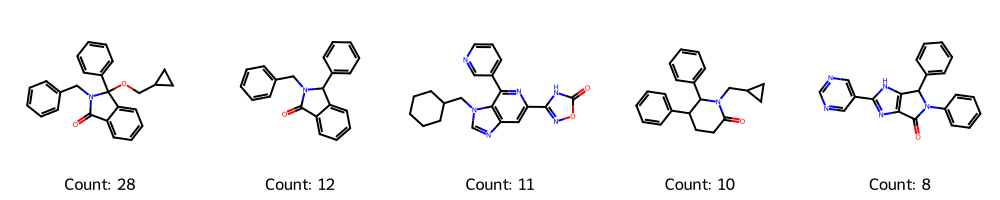


Computing t-SNE (this might take a moment)...


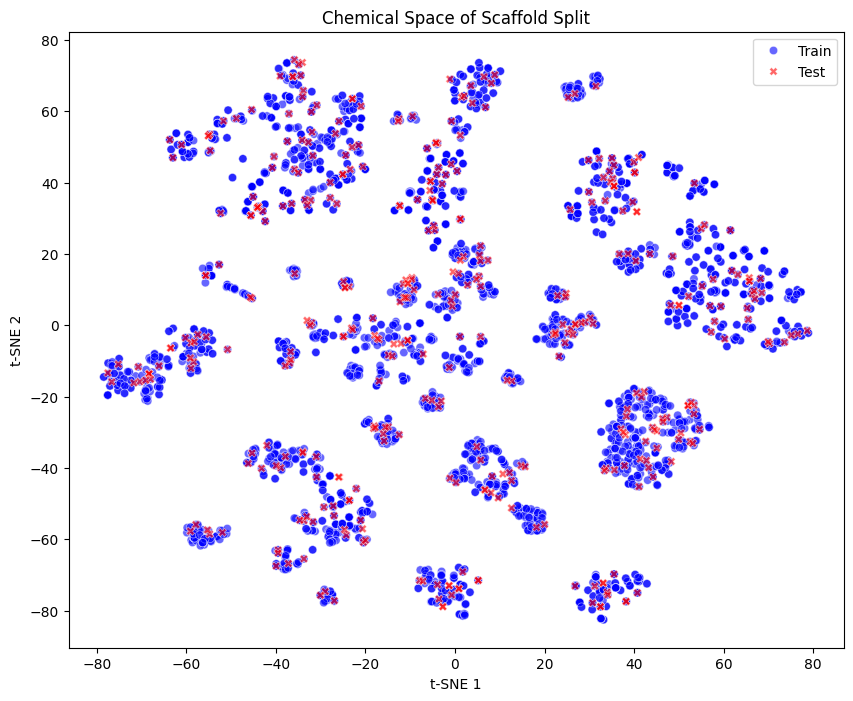

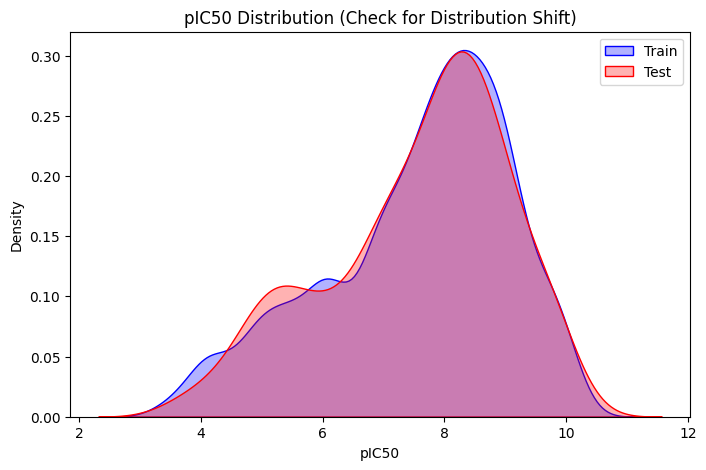

In [17]:
torch.manual_seed(42)  # Fixed seed for reproducibility
num_samples = len(mol_data)
indices = torch.randperm(num_samples).tolist()

train_size = int(0.8 * num_samples)
val_size = int(0.1 * num_samples)
test_size = num_samples - train_size - val_size

# Slice the Indices
train_indices_random = indices[:train_size]
val_indices_random = indices[train_size : train_size + val_size]
test_indices_random = indices[train_size + val_size :]

visualize_scaffold_split(mol_data, train_indices_random, val_indices_random, test_indices_random)

## Modeling

### Graph Network v5 - GATv2Conv Layers. Add Bond Attributes. Add Atom Features.

/Users/dantrainer/projects/cancer_research/src/mdm2_breaker/featurizers.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with

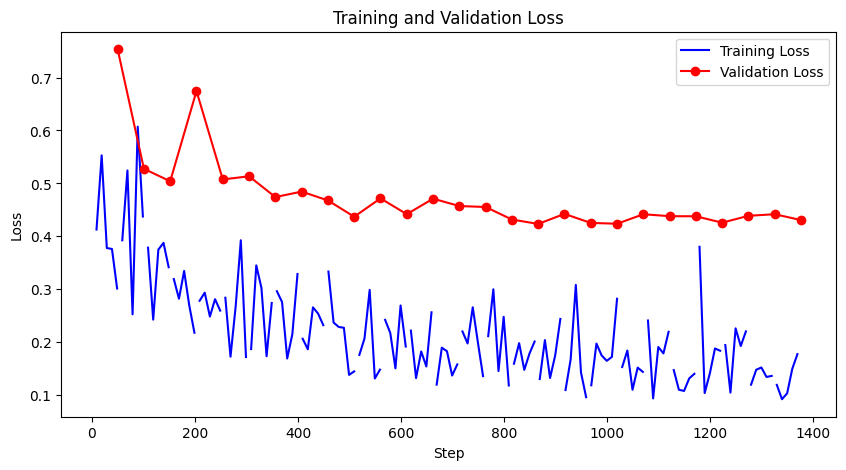

In [18]:
protein_graph = protein_data.get_graph()

model_v5, train_loader_v5, val_loader_v5, test_loader_v5 = train_model(
    model=GraphSiameseNetwork_v5(),
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_data=protein_graph,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name="Model-v5_1-updated",
)
plot_loss("lightning_logs/version_7/metrics.csv")

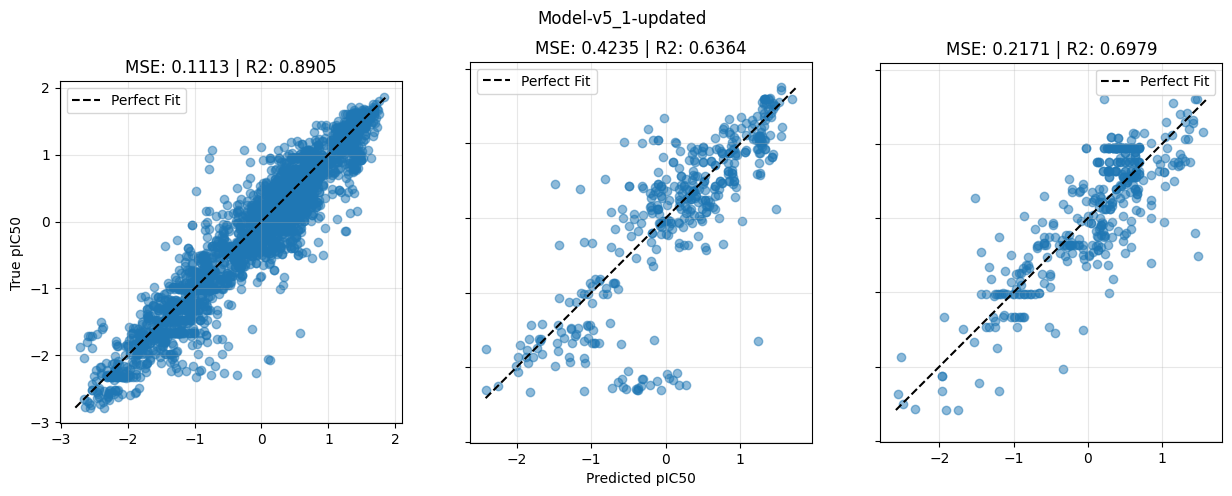

In [19]:
model_v5 = load_model_from_checkpoint(
    GraphSiameseNetwork_v5, "checkpoints/Model-v5_1-updated.ckpt"
)
plot_predictions(
    model_v5,
    (train_loader_v5, val_loader_v5, test_loader_v5),
    protein_graph,
    "Model-v5_1-updated",
)

Running t-SNE...


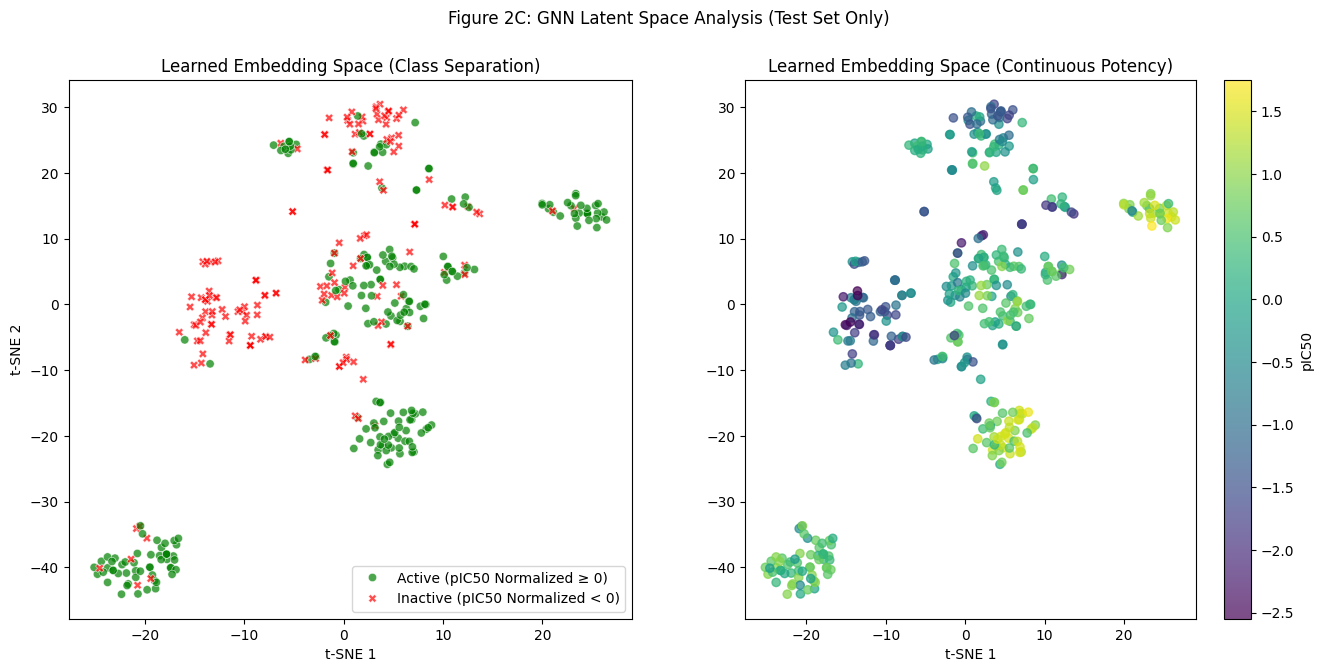

In [20]:
def plot_latent_space(model, test_indices, mol_data):
    embeddings = []
    activities = []
    labels = []
    threshold = 0

    with torch.no_grad():
        for idx in test_indices:
            data = mol_data[idx]
            
            # 1. Extract the Molecule Embedding (Graph Part Only)
            # This corresponds to the 'mol_vec' in your forward pass
            # Shape: [1, 256] (128 sum + 128 max)
            mol_vec = model.encode_molecule(data)
            
            # Store as numpy
            embeddings.append(mol_vec.cpu().numpy())
            
            # Store Truth
            pIC50 = data.y.item()
            activities.append(pIC50)
            
            # Define Label
            if pIC50 >= threshold:
                labels.append(f"Active (pIC50 Normalized ≥ {threshold})")
            else:
                labels.append(f"Inactive (pIC50 Normalized < {threshold})")

        # Concatenate
        X = np.concatenate(embeddings, axis=0)
        y_continuous = np.array(activities)
        y_discrete = np.array(labels)
        
        # 2. Run t-SNE
        print("Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
        X_embedded = tsne.fit_transform(X)
        
        # 3. Plotting
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))
        
        # Plot A: Discrete (Active vs Inactive)
        sns.scatterplot(
            x=X_embedded[:, 0], 
            y=X_embedded[:, 1], 
            hue=y_discrete,
            style=y_discrete,
            palette={f"Active (pIC50 Normalized ≥ {threshold})": "green", f"Inactive (pIC50 Normalized < {threshold})": "red"},
            alpha=0.7,
            ax=ax[0]
        )
        ax[0].set_title("Learned Embedding Space (Class Separation)")
        ax[0].set_xlabel("t-SNE 1")
        ax[0].set_ylabel("t-SNE 2")
        
        # Plot B: Continuous (Gradient)
        sc = ax[1].scatter(
            X_embedded[:, 0], 
            X_embedded[:, 1], 
            c=y_continuous, 
            cmap="viridis", 
            alpha=0.7
        )
        plt.colorbar(sc, ax=ax[1], label="pIC50")
        ax[1].set_title("Learned Embedding Space (Continuous Potency)")
        ax[1].set_xlabel("t-SNE 1")
        
        plt.suptitle("Figure 2C: GNN Latent Space Analysis (Test Set Only)")
        plt.show()

plot_latent_space(model_v5, test_indices_random, mol_data)

Running t-SNE...


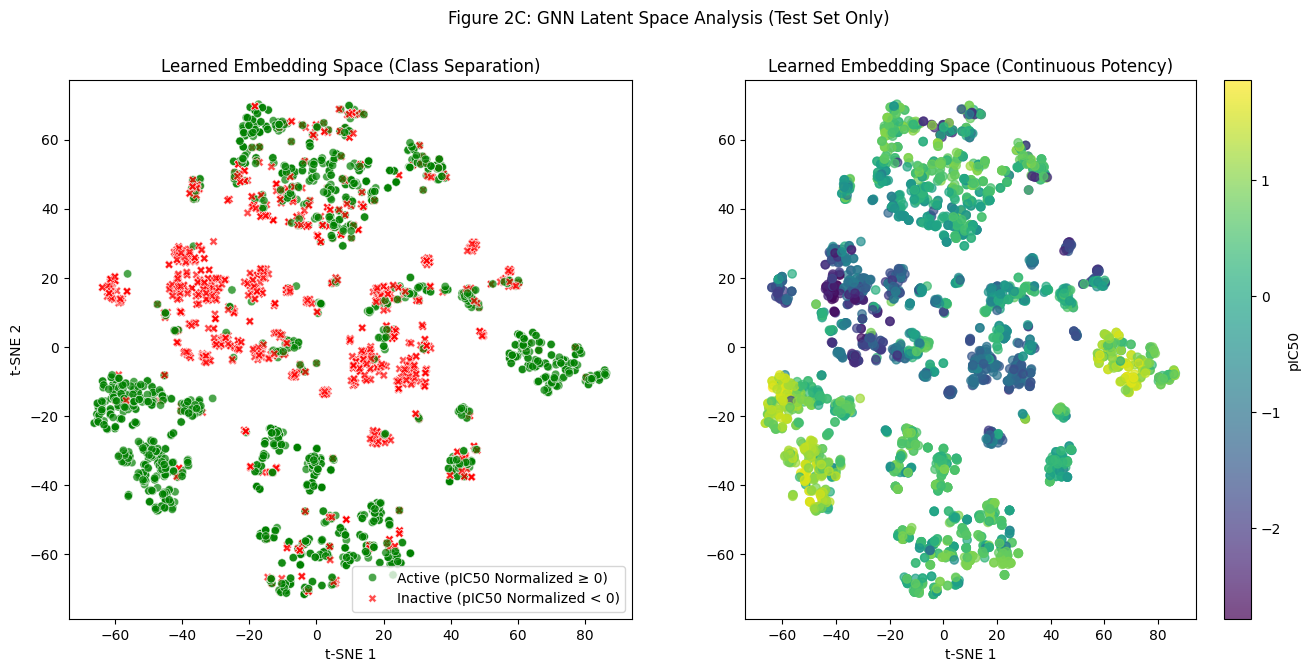

In [21]:
plot_latent_space(model_v5, train_indices_random, mol_data)

Running t-SNE...


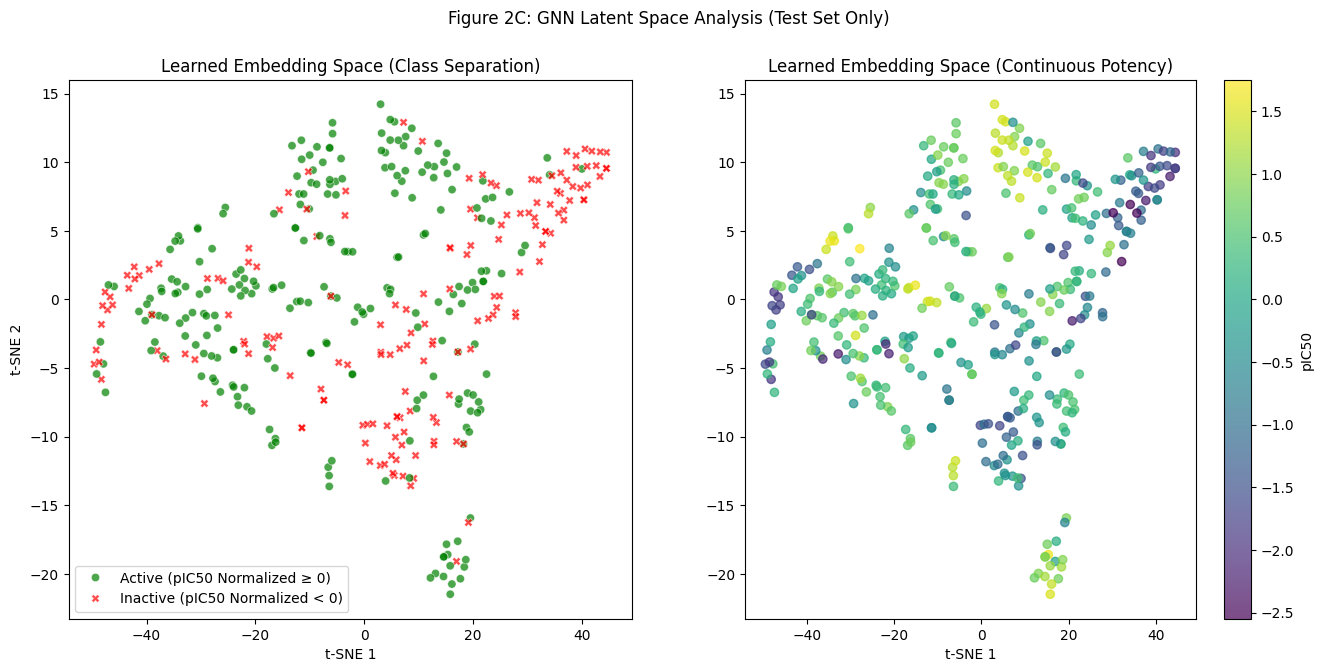

Running t-SNE...


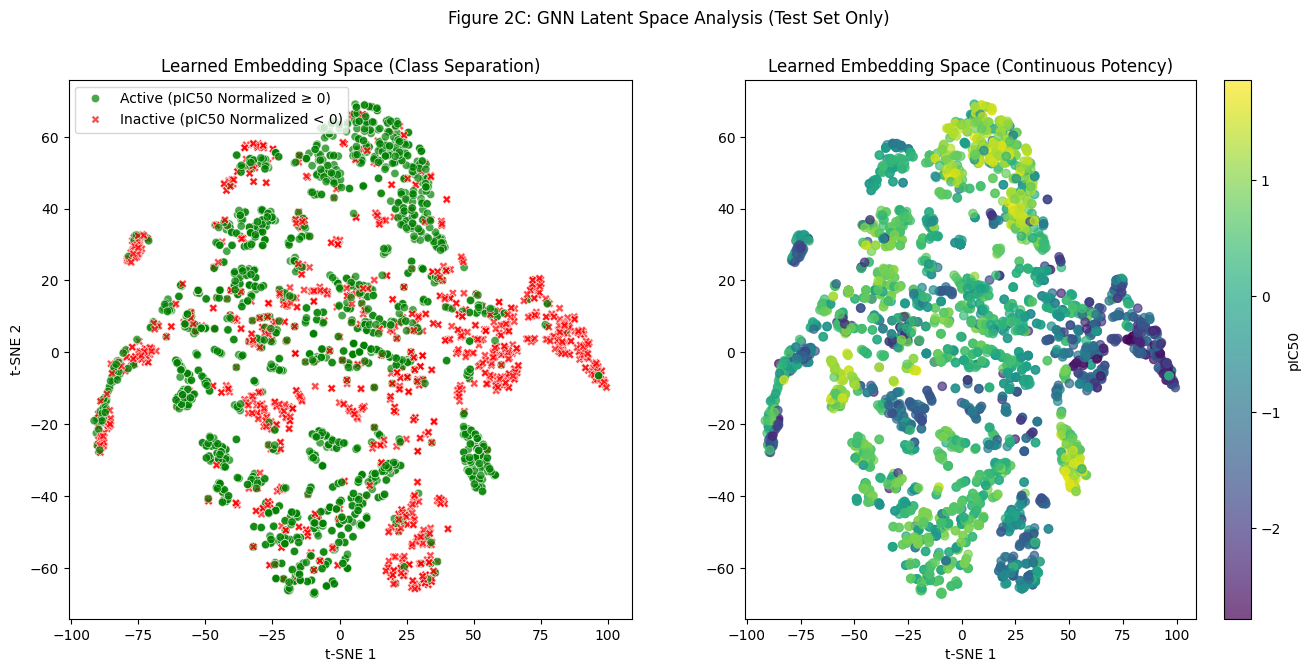

In [22]:
untrained_model = GraphSiameseNetwork_v5()
plot_latent_space(untrained_model, test_indices_random, mol_data)
plot_latent_space(untrained_model, train_indices_random, mol_data)

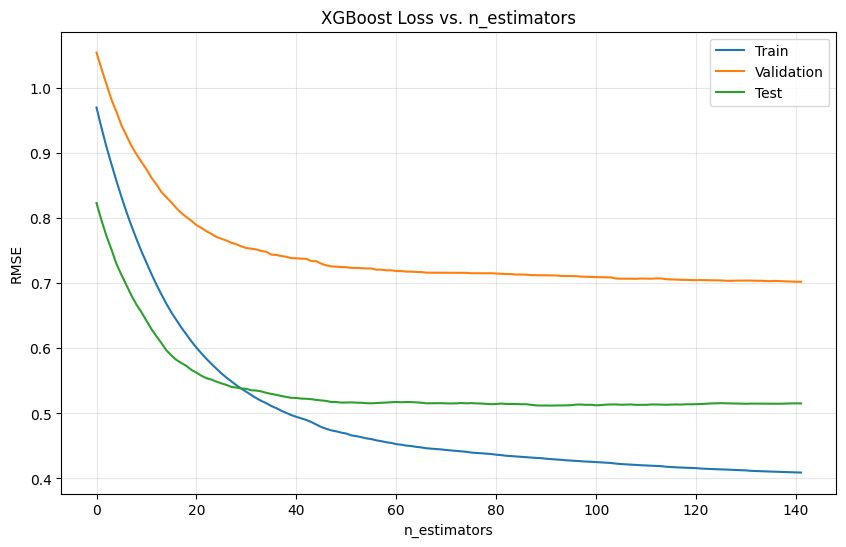

Best Iteration: 91
Best Score (Validation MSE): 0.5118


In [23]:
import xgboost as xgb

# Apply to the CSV for XGBoost
train_df = df_mol.iloc[train_indices]
val_df = df_mol.iloc[val_indices]
test_df = df_mol.iloc[test_indices]

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=50,
)

X_test = np.stack(np.array(test_df["fingerprint"]))
y_test = test_df["pIC50_norm"].values
X_train = np.stack(np.array(train_df["fingerprint"]))
y_train = train_df["pIC50_norm"].values
X_val = np.stack(np.array(val_df["fingerprint"]))
y_val = val_df["pIC50_norm"].values

xgb_model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_train, y_train),(X_val, y_val),(X_test, y_test)], 
    verbose=False)

y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_val = np.mean((y_pred_val - y_val) ** 2)
mse_test = np.mean((y_pred_test - y_test) ** 2)

plot_xgb_loss(xgb_model)

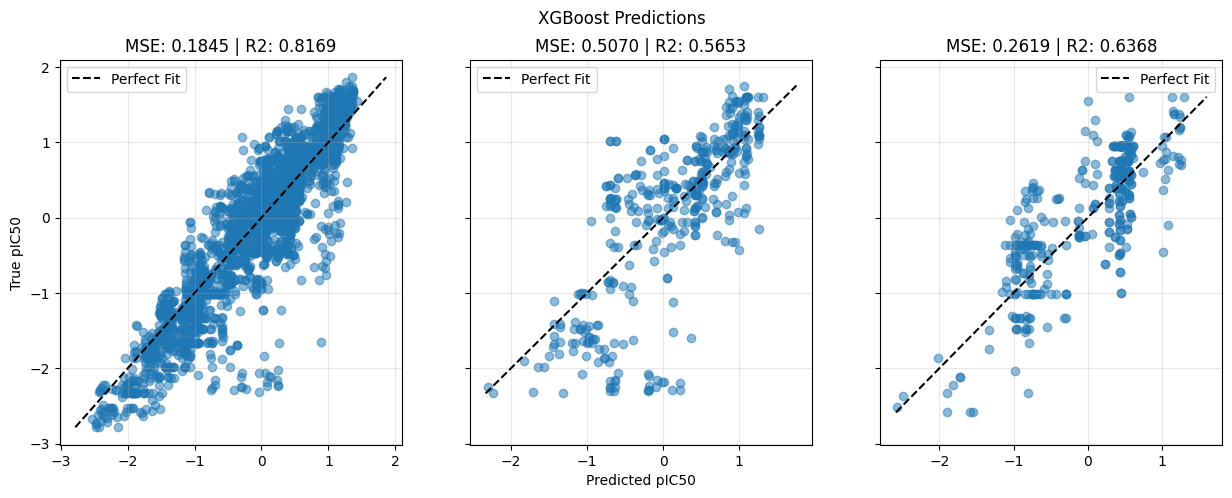

In [24]:
plot_xgboost_predictions(
    pred_train_mse_tuple=(y_pred_train, y_train, mse_train),
    pred_val_mse_tuple=(y_pred_val, y_val, mse_val),
    pred_test_mse_tuple=(y_pred_test, y_test, mse_test),
)
del xgb_model, y_pred_train, y_pred_val, y_pred_test, mse_train, mse_val, mse_test

## Check Autodock-Vina Benchmark

In [25]:
import os
import subprocess
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from scipy.spatial import distance
from tqdm import tqdm 

class AutoDockRunner:
    def __init__(self, receptor_pdb_path, work_dir="vina_benchmark"):
        self.receptor_pdb = receptor_pdb_path
        self.work_dir = work_dir
        self.receptor_pdbqt = os.path.join(work_dir, "receptor.pdbqt")
        
        os.makedirs(work_dir, exist_ok=True)
        
    def prepare_receptor(self):
        """
        Converts the PDB receptor to PDBQT format using OpenBabel.
        Note: For a 'Scientific Leader' grade benchmark, you'd usually use 
        MGLTools to handle protonation carefully, but OpenBabel is standard for high-throughput baselines.
        """
        print(f"Converting Receptor {self.receptor_pdb} to PDBQT...")
        # -xr: rigid molecule, -h: add hydrogens
        cmd = f"obabel {self.receptor_pdb} -O {self.receptor_pdbqt} -xr -h --partialcharge gasteiger"
        subprocess.run(cmd, shell=True, check=True)
        
    def get_pocket_center(self, pdb_file):
        """
        Calculates the center of the binding pocket based on the bound ligand (p53 peptide chain B).
        Crucial: Vina needs to know WHERE to look.
        """
        # Simple parser to find Chain B (the p53 peptide in 1YCR)
        coords = []
        # Inside get_pocket_center
        target_residues = {'19', '23', '26'} # PDB residue numbers for Phe, Trp, Leu
        coords = []
        with open(pdb_file, 'r') as f:
            for line in f:
                if line.startswith("ATOM") and line[21] == 'B':
                    res_seq = line[22:26].strip()
                    if res_seq in target_residues:
                        x = float(line[30:38])
                        y = float(line[38:46])
                        z = float(line[46:54])
                        coords.append([x, y, z])
        
        if not coords:
            print("Warning: Could not find Chain B (peptide) to define pocket center. Using geometric center.")
            # Fallback logic if needed
            return [0, 0, 0]
            
        center = np.mean(coords, axis=0)
        print(f"Calculated Pocket Center: {center}")
        return center

    def prepare_ligand(self, smiles, lig_id):
        """
        1. Generates 3D Conformer with RDKit
        2. Converts to PDBQT with OpenBabel
        """
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        
        mol = Chem.AddHs(mol)
        try:
            # Generate 3D coordinates
            AllChem.MMFFOptimizeMolecule(mol)
            res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
            if res == -1:
                # Try with random coords if ETKDG fails
                res = AllChem.EmbedMolecule(mol, AllChem.ETKDG(), useRandomCoords=True)
                if res == -1: return None # Give up if both fail
        except:
            return None
            
        # Save temp SDF
        sdf_path = os.path.join(self.work_dir, f"lig_{lig_id}.sdf")
        pdbqt_path = os.path.join(self.work_dir, f"lig_{lig_id}.pdbqt")
        
        writer = Chem.SDWriter(sdf_path)
        writer.write(mol)
        writer.close()
        
        # Convert to PDBQT
        cmd = f"obabel {sdf_path} -O {pdbqt_path} -h --partialcharge gasteiger"
        subprocess.run(cmd, shell=True, stderr=subprocess.DEVNULL)
        
        return pdbqt_path

    def run_vina(self, lig_pdbqt, center, size=(20, 20, 20)):
        """
        Runs Vina and parses the best affinity score.
        """
        out_pdbqt = lig_pdbqt.replace(".pdbqt", "_out.pdbqt")
        log_file = lig_pdbqt.replace(".pdbqt", ".log")
        
        # Construct Vina Command
        # exhaustiveness=8 is default. Increase to 32 for "Paper Quality" results (slower)
        cmd = (
            f"vina --receptor {self.receptor_pdbqt} --ligand {lig_pdbqt} "
            f"--center_x {center[0]} --center_y {center[1]} --center_z {center[2]} "
            f"--size_x {size[0]} --size_y {size[1]} --size_z {size[2]} "
            f"--exhaustiveness 8 --out {out_pdbqt} > {log_file}"
        )
        
        try:
            subprocess.run(cmd, shell=True, check=True)
            
            # Parse the Log file for the best score (Top mode)
            with open(log_file, 'r') as f:
                for line in f:
                    if line.strip().startswith("1"):
                        # Output format: mode | affinity | dist...
                        # Example:   1        -9.4      0.000
                        parts = line.split()
                        if len(parts) >= 2:
                            return float(parts[1]) # The Affinity (kcal/mol)
        except Exception as e:
            print(f"Vina failed: {e}")
            return None
            
        return None


In [26]:
# # --- EXECUTION ---
# # 1. Initialize
# runner = AutoDockRunner(receptor_pdb_path=os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb"))
# runner.prepare_receptor()
# pocket_center = runner.get_pocket_center(runner.receptor_pdb)

In [27]:
# # 2. Run on Test Set (Select a subset of ~50-100 molecules to save time)
# # Full Vina runs can take 10-30 seconds per molecule.

# vina_results = []
# for idx in tqdm(test_indices):
#     smiles = df_mol.iloc[idx]['SMILES']
#     true_pic50 = df_mol.iloc[idx]['pIC50']
    
#     # Prep & Dock
#     lig_path = runner.prepare_ligand(smiles, idx)
#     if lig_path:
#         score = runner.run_vina(lig_path, pocket_center)
#         if score is not None:
#             vina_results.append({
#                 "idx": idx,
#                 "SMILES": smiles,
#                 "Vina_Affinity_kcal": score,
#                 "True_pIC50": true_pic50
#             })

# # 3. Analyze
# df_vina = pd.DataFrame(vina_results)
# df_vina.to_csv("vina_results.csv", index=False)
# print("Done!")

In [28]:
def vina_to_pic50(delta_g_kcal):
    """
    Converts AutoDock Vina score (kcal/mol) to pIC50.
    Assumes T = 298.15 K.
    """
    R = 1.98720425864083e-3  # Gas constant in kcal/(mol·K)
    T = 298.15               # Temperature in Kelvin
    
    # 1. Convert Delta G to Ki (Molar)
    # Ki = exp(DeltaG / RT)
    ki_molar = np.exp(delta_g_kcal / (R * T))
    
    # 2. Convert Ki to pIC50
    # pIC50 = -log10(Ki)
    pic50 = -np.log10(ki_molar)
    
    return pic50
    

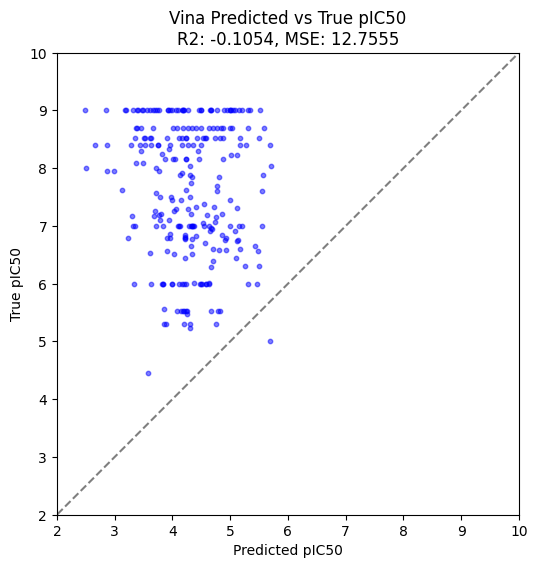

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_vina = pd.read_csv("vina_results.csv")
df_vina['vina_pred_pic50'] = df_vina['Vina_Affinity_kcal'].apply(vina_to_pic50)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_vina.plot(
    x='vina_pred_pic50',
    y='True_pIC50',
    kind='scatter',
    alpha=0.5,
    color='blue',
    s=10,
    ax=ax
)
r2 = df_vina['vina_pred_pic50'].corr(df_vina['True_pIC50'])
mse = np.mean((df_vina['vina_pred_pic50'] - df_vina['True_pIC50']) ** 2)
plt.xlim(2, 10)
plt.ylim(2, 10)
ax.set_aspect('equal', 'box')
plt.plot([0, 14], [0, 14], 'k--', alpha=0.5)
plt.xlabel('Predicted pIC50')
plt.ylabel('True pIC50')
plt.title(f'Vina Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}')
plt.show()


## Check Graph DTA

In [30]:
# 1. Create the new Sequence Encoder (Freshly initialized)
seq_encoder = ProteinSequenceEncoder(output_dim=128) # The class I gave you earlier
uninitialized_graph_model = GraphSiameseNetwork_v5()
# 2. Assemble the Hybrid Model
# Note: We pass 'model_v5.encode_molecule' as the encoder function
hybrid_model = SequenceSiameseNetwork(
    molecule_encoder=uninitialized_graph_model.encode_molecule, 
    sequence_encoder=seq_encoder,
)

# # 4. (Optional) Freeze the Molecule side to test purely the Protein Signal
for param in hybrid_model.parameters():
    param.requires_grad = True

In [31]:
def train_model(
    model,
    mol_class,
    protein_data,
    train_indices,
    val_indices,
    test_indices,
    epochs=100,
    lr=1e-4,
    save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}",
):
    trainer = define_trainer(epochs=epochs, lr=lr, save_name=save_name)

    train_loader, val_loader, test_loader = generate_loaders(
        mol_class, train_indices, val_indices, test_indices
    )

    system = SarcomaScoutSystem(model=model, protein_data=protein_data, lr=lr)

    # trainer.fit(system, train_loader, val_loader)

    return model, train_loader, val_loader, test_loader

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


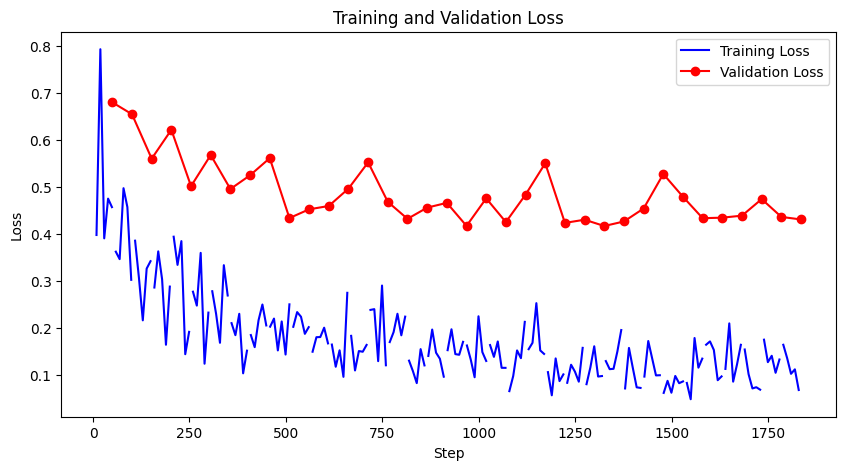

In [32]:
MDM2_SEQUENCE = "SQIPASEQETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDEKQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVVVNQQESSDSGTSVSEN"

# Simple Amino Acid Vocabulary
AA_VOCAB = "ACDEFGHIKLMNPQRSTVWY" # The 20 standard
char_to_int = {c: i+1 for i, c in enumerate(AA_VOCAB)} # Start at 1, 0 is padding

def tokenize_sequence(seq, max_len=1000):
    # Convert chars to ints, ignoring unknown chars
    indices = [char_to_int.get(c, 0) for c in seq]
    
    # Pad or Truncate
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        
    return torch.tensor(indices, dtype=torch.long)

# Usage
mdm2_tensor = tokenize_sequence(MDM2_SEQUENCE).unsqueeze(0) # Add batch dim

model_gdta, train_loader_gdta, val_loader_gdta, test_loader_gdta = train_model(
    model=hybrid_model,
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_data=mdm2_tensor,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR*10,
    save_name="Model-GraphDTA_from_scratch",
)
plot_loss("lightning_logs/version_11/metrics.csv")

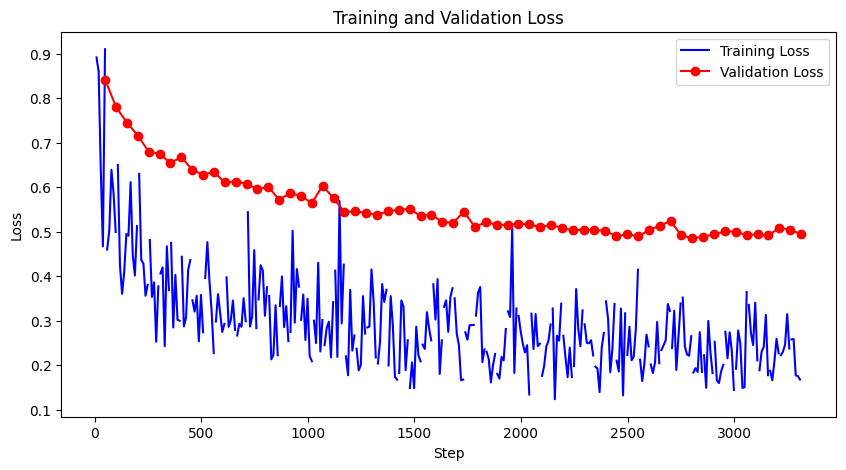

In [33]:
plot_loss("lightning_logs/version_9/metrics.csv")

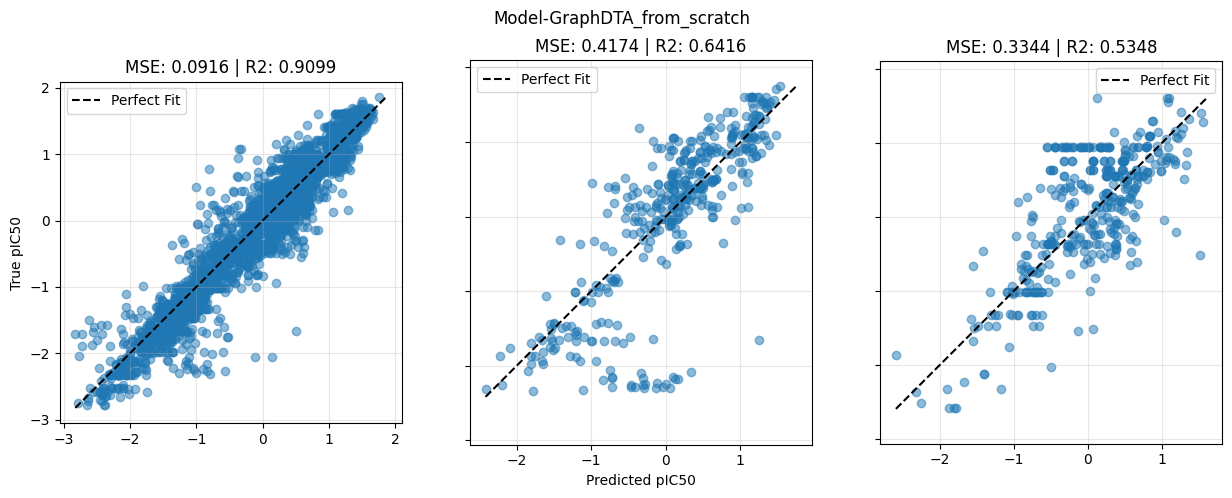

In [34]:
# 1. Load the raw checkpoint
checkpoint = torch.load(os.path.join("checkpoints", "Model-GraphDTA_from_scratch.ckpt"))
state_dict = checkpoint["state_dict"]

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model_gdta = SequenceSiameseNetwork(
    molecule_encoder=uninitialized_graph_model.encode_molecule, 
    sequence_encoder=seq_encoder,
)

# 4. Load the cleaned weights
model_gdta.load_state_dict(new_state_dict)
model_gdta.eval()

plot_predictions(
    model_gdta,
    (train_loader_gdta, val_loader_gdta, test_loader_gdta),
    mdm2_tensor,
    "Model-GraphDTA_from_scratch",
)

In [35]:
df_gdta = pd.read_csv(os.path.join(ROOT, 'data', 'MDM2_Breaker', 'processed', 'graphdta_benchmark_results.csv'))
df_gdta.head()


,SMILES,pIC50,pIC50_pred
0,CC(C)(C)S(=O)(=O)C[C@H](C1CCC1)N1[C@@H]([C@H](...,10.000000,8.938341
1,CC(C)S(=O)(=O)C[C@H](C1CCC1)N1[C@@H]([C@H](C[C...,10.000000,8.943728
2,CC[C@@H](CN(c1ccc(F)cc1)S(=O)(=O)C1CC1)N1[C@@H...,9.221849,8.372227
3,CC[C@](O)(C1CCN(C)CC1)c1cc2C(=O)N(Cc3ncc(Cl)cn...,9.221849,8.151003
4,CC[C@](O)(C1CCN(C)CC1)c1cc2C(=O)N(Cc3ncc(Cl)cn...,9.221849,8.151003


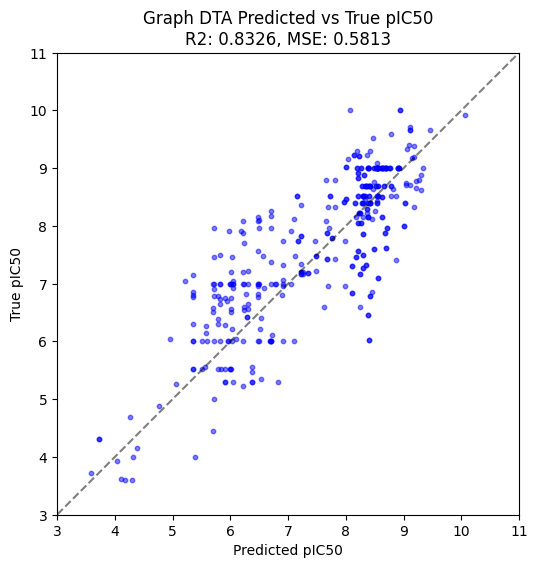

In [36]:
_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_gdta.plot(
    x='pIC50_pred',
    y='pIC50',
    kind='scatter',
    alpha=0.5,
    color='blue',
    s=10,
    ax=ax
)
r2 = df_gdta['pIC50_pred'].corr(df_gdta['pIC50'])
mse = np.mean((df_gdta['pIC50_pred'] - df_gdta['pIC50']) ** 2)
plt.xlim(3, 11)
plt.ylim(3, 11)
ax.set_aspect('equal', 'box')
plt.plot([0, 14], [0, 14], 'k--', alpha=0.5)
plt.xlabel('Predicted pIC50')
plt.ylabel('True pIC50')
plt.title(f'Graph DTA Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}')
plt.show()